# 33 — Positional Encoding and Transformer Inputs

[Notebook 32](./32_multi_head_attention.ipynb) built multi-head attention. Attention compares token representations, but by itself it does not know whether a token occurs first, last, or next to another token. This notebook adds positional information before we construct a complete Transformer block.

## Learning objectives

- explain why self-attention needs explicit positional information;
- demonstrate the permutation-equivariant behavior of attention;
- implement sinusoidal positional encodings;
- visualize how sine and cosine frequencies vary across positions;
- combine token and positional representations;
- compare fixed sinusoidal and learned positional embeddings.


In [40]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.attention import multi_head_attention_forward

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)


## 1. Self-attention does not contain sequence order

Self-attention processes queries and keys through content-based dot products. If we apply the same permutation to the input token positions, the output positions receive the same permutation. This property is called **permutation equivariance**:

$$
f(PX)=P f(X),
$$

where $P$ reorders the sequence positions. Equivariance is not the same as invariance: the output is reordered rather than remaining identical. However, the operation still has no information about the original order.

For example, the token representations for `dog bites person` and `person bites dog` contain the same set of tokens. Without positional information, self-attention sees only their content and the reordered outputs. It has no independent signal telling it which noun came first.

### Exercise 1 — Verify permutation equivariance


In [41]:
batch_size, sequence_length, model_dim = 1, 4, 6
num_heads = 2
x = generator.normal(size=(batch_size, sequence_length, model_dim))
permutation = np.array([2, 0, 3, 1])

# Use identity projections so the experiment focuses on position order.
identity = np.eye(model_dim)
zero_bias = np.zeros(model_dim)

def self_attention(sequence):
    output, _, _ = multi_head_attention_forward(
        sequence, sequence, sequence,
        identity, identity, identity, identity,
        zero_bias, zero_bias, zero_bias, zero_bias,
        num_heads=num_heads,
    )
    return output

original_output = self_attention(x)
permuted_x = x[:, permutation]
permuted_output = self_attention(permuted_x)

# reorder original_output with the same permutation.
expected_permuted_output = original_output[:, permutation]

np.testing.assert_allclose(permuted_output, expected_permuted_output)


## 2. Sinusoidal positional encoding

A positional encoding is a vector associated with a position rather than a token identity. The original Transformer uses fixed sine and cosine functions:

$$
PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/D}}\right),
$$

$$
PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/D}}\right).
$$

Here `pos` is a sequence position, $D$ is the model dimension, and $i$ indexes a sine/cosine pair. Dimensions use different frequencies: low-index dimensions change quickly, while high-index dimensions change slowly. Every position consequently receives a distinct pattern across dimensions.

If $D=32$, all 32 dimensions receive positional values, arranged as 16 sine/cosine pairs. Dimensions 0 and 1 form the fastest-changing pair, dimensions 2 and 3 form a slightly slower pair, and dimensions 30 and 31 form the slowest pair. No single dimension is expected to identify a position by itself; the complete 32-value pattern acts as its positional fingerprint.

Different frequencies describe position at different scales. In a fast-changing dimension, nearby positions such as 1 and 5 can already have substantially different values. In a slow-changing dimension, positions 1 and 5 may look almost identical, while a larger separation such as 1 and 100 produces more change. Because sine and cosine are periodic, distant positions can occasionally look similar in one dimension, but it is much less likely that they match across all frequencies.

A useful analogy is several clock hands: a second hand changes rapidly, a minute hand changes more slowly, and an hour hand records broader progress. One hand eventually repeats, but their combined configuration is more informative than any hand alone.

After positional encoding is added to a token embedding, dimensions are not permanently divided into `position dimensions` and `content dimensions`. Every input dimension contains a token value plus a positional value. Learned query, key, and value projections can combine all dimensions and decide which positional scales are useful for the task.

An implementation can first calculate the angles for the paired dimensions:

```text
positions:       (L, 1)
pair indices:    (ceil(D / 2),)
angle rates:     (ceil(D / 2),)
angles:          (L, ceil(D / 2))
encoding:        (L, D)
```

The same angle column supplies an even sine dimension and, when it exists, the following odd cosine dimension.

### Exercise 2 — Implement sinusoidal positional encoding


In [42]:
def sinusoidal_positional_encoding(sequence_length, model_dim):
    """Return fixed positional encodings with shape (L, D)."""
    # validate that both arguments are positive integers.
    if (
        isinstance(sequence_length, (bool, np.bool_))
        or not isinstance(sequence_length, (int, np.integer))
        or isinstance(model_dim, (bool, np.bool_))
        or not isinstance(model_dim, (int, np.integer))
    ):
        raise TypeError("sequence_length and model_dim must be integers")

    if sequence_length <= 0 or model_dim <= 0:
        raise ValueError("sequence_length and model_dim must be positive")
    # create positions with shape (L, 1).
    positions = np.arange(sequence_length)[:, None]
    # print(f"Positions shape: {positions.shape}, values:\n{positions}")
    # create paired dimension indices 0, 2, 4, ... .
    even_dimensions = np.arange(0, model_dim, 2)
    # print(f"Dimension indices shape: {even_dimensions.shape}, values:\n{even_dimensions}")
    # calculate angles and fill even dimensions with sine.
    angles = positions / (np.power(10000, even_dimensions / model_dim))
    # print(f"Angles shape: {angles.shape}, values:\n{angles}")
    encoding = np.zeros((sequence_length, model_dim))
    encoding[:, 0::2] = np.sin(angles)
    # print(f"Encoding shape: {encoding.shape}, values:\n{encoding}")
    number_of_odd_dimensions = encoding[:, 1::2].shape[1]
    encoding[:, 1::2] = np.cos(angles[:, :number_of_odd_dimensions])
    # print(f"Final encoding shape: {encoding.shape}, values:\n{encoding}")
    return encoding


small_encoding = sinusoidal_positional_encoding(4, 6)
assert small_encoding.shape == (4, 6)
np.testing.assert_allclose(small_encoding[0, 0::2], 0.0)
np.testing.assert_allclose(small_encoding[0, 1::2], 1.0)
np.testing.assert_allclose(small_encoding[:, 0], np.sin(np.arange(4)))
np.testing.assert_allclose(small_encoding[:, 1], np.cos(np.arange(4)))


## 3. Visualize positional patterns

A heatmap makes the frequency structure easier to see. The horizontal axis represents model dimensions and the vertical axis represents positions. Neighboring positions have related but different encodings.

### Exercise 3 — Plot the encoding and selected dimensions


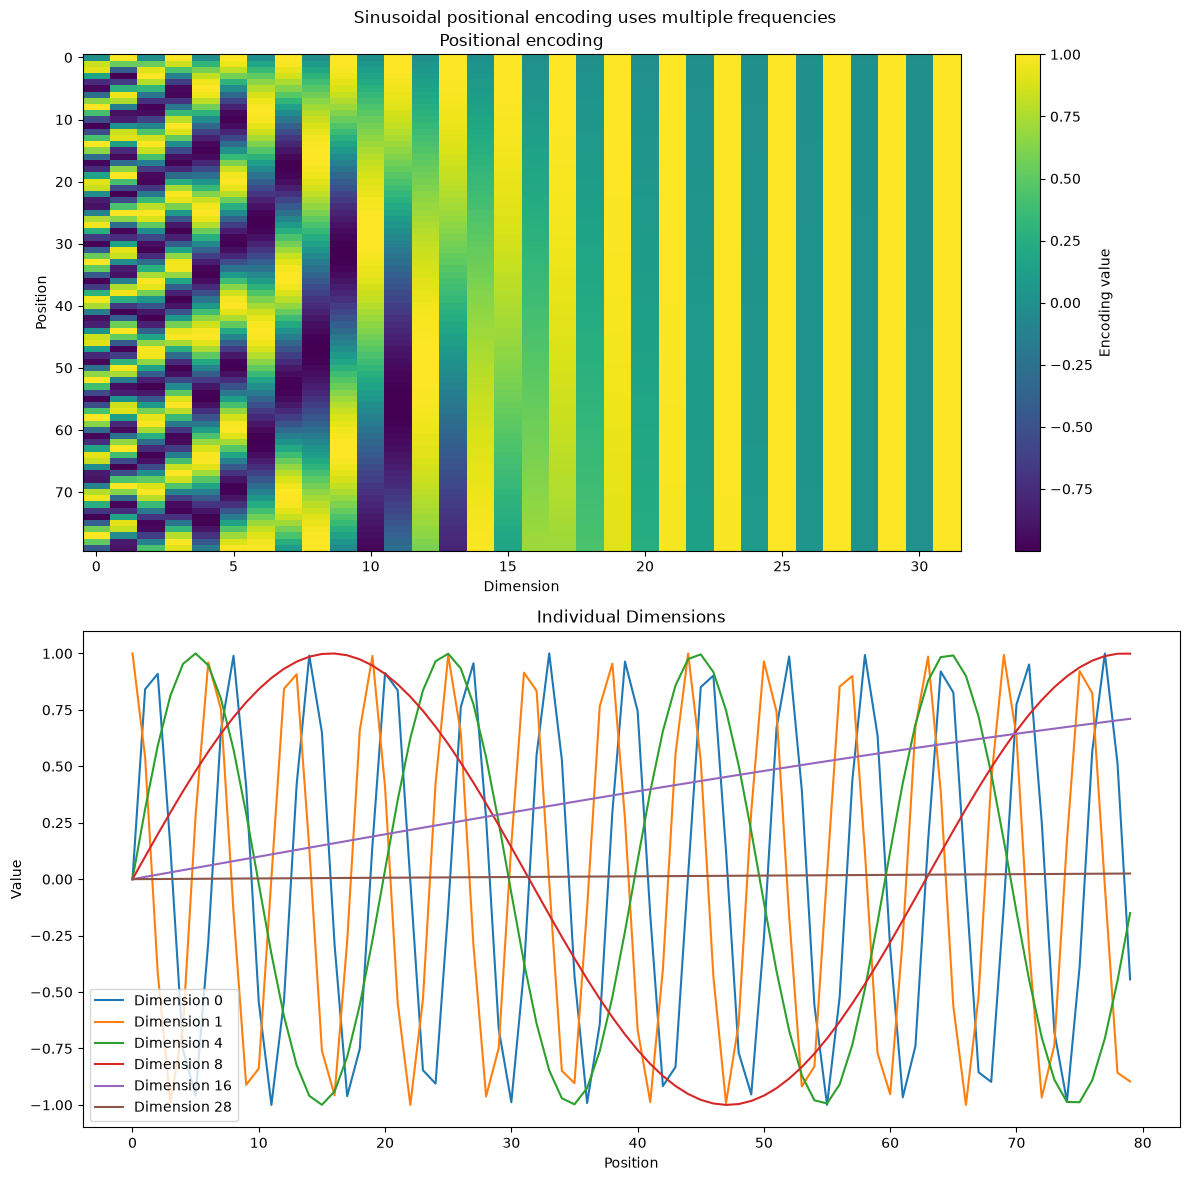

In [43]:
encoding = sinusoidal_positional_encoding(sequence_length=80, model_dim=32)
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# show encoding as a heatmap on axes[0].
# Label its axes and add a colorbar.
heatmap = axes[0].imshow(
    encoding,
    aspect="auto",
    cmap="viridis",
)

axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Position")
axes[0].set_title("Positional encoding")

fig.colorbar(
    heatmap,
    ax=axes[0],
    label="Encoding value",
)

# plot dimensions 0, 4, 16, and 28 against position on axes[1].
# Label the axes and add a legend.
for dim in [0, 1, 4, 8, 16, 28]:
    axes[1].plot(encoding[:, dim], label=f'Dimension {dim}')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].set_title('Individual Dimensions')
axes[1].legend()

fig.suptitle("Sinusoidal positional encoding uses multiple frequencies")
plt.tight_layout()
plt.show()


## 4. Combine token and position representations

Token embeddings and positional encodings both have width $D$, so the usual combination is element-wise addition:

$$
X_{input}=X_{token}+X_{position}.
$$

Addition preserves shape $(N,L,D)$ and lets every later projection use token content and position together. Concatenation would increase the width and require additional parameters to map it back to the model dimension.

The encoding has shape $(L,D)$ and broadcasts over the batch dimension when added to token embeddings $(N,L,D)$.

### Exercise 4 — Add positional information and break equivariance


In [44]:
position_encoding = sinusoidal_positional_encoding(sequence_length, model_dim)

# First sequence: tokens occupy their original positions.
positioned_x = x + position_encoding
positioned_output = self_attention(positioned_x)

# Second sequence: permute the tokens but keep positions 0, 1, 2, 3 fixed.
permuted_positioned_x = permuted_x + position_encoding
permuted_positioned_output = self_attention(permuted_positioned_x)

# compare with positioned_output reordered by permutation.
# They should no longer be equal because each token now receives a new position.
reordered_positioned_output = positioned_output[:, permutation]
maximum_difference = np.max(np.abs(permuted_positioned_output - reordered_positioned_output))


print(f"Maximum difference after adding positions: {maximum_difference:.6f}")
assert maximum_difference > 1e-3


Maximum difference after adding positions: 1.728512


## 5. Fixed versus learned positional embeddings

Sinusoidal encodings contain no trainable parameters and can be calculated for positions beyond those seen during training. A learned positional embedding is instead a parameter table with shape $(L_{max},D)$. Position indices retrieve rows from that table, just as token IDs retrieve word embeddings.

Learned positions can adapt freely to the training task, but the table has a fixed maximum length and positions not trained effectively have untrained rows. Modern architectures use several positional strategies, including learned absolute positions and relative or rotary position representations.

### Exercise 5 — Retrieve learned positional embeddings


In [45]:
maximum_length = 10
learned_position_table = generator.normal(
    scale=0.02, size=(maximum_length, model_dim)
)
position_ids = np.arange(sequence_length)

# retrieve one learned vector for every position in position_ids.
learned_positions = learned_position_table[position_ids]
# add the result to x using batch broadcasting.
learned_positioned_x = x + learned_positions

assert learned_positions.shape == (sequence_length, model_dim)
assert learned_positioned_x.shape == x.shape
np.testing.assert_allclose(
    learned_positioned_x[0, 2], x[0, 2] + learned_position_table[2]
)


## Reflection

Answer briefly in your own words.

1. What does permutation equivariance mean for self-attention?
2. Why does self-attention alone not know token order?
3. Why do sinusoidal encodings use several frequencies?
4. Why are token and positional vectors usually added instead of concatenated?
5. What is one advantage and one limitation of learned positional embeddings?
6. In Exercise 4, why do permuted tokens no longer produce merely permuted outputs?

### Answers


1. If input positions are permuted, self-attention produces the same output vectors with the corresponding permutation. The values follow the reordered positions rather than remaining in their original order.

2. Queries, keys, and values are calculated from token content. Without positional information or an order-dependent mask, nothing in the operation identifies which token was first, second, or last.

3. Different frequencies represent position at different scales. Fast-changing dimensions distinguish nearby positions, while slow-changing dimensions preserve broader positional patterns.

4. Addition preserves the model dimension and combines token and position information in every feature. Concatenation would increase the representation width and require another projection.

5. Learned positional embeddings can adapt specifically to the training task. Their limitation is a fixed table size, and positions not encountered during training do not receive meaningfully trained representations.

6. The tokens were permuted, but the positional vectors stayed attached to positions `0, 1, 2, 3`. Each token therefore received a different positional vector, changing its queries, keys, values, attention weights, and output—not merely the output order.

